# **Working on new dataset**

In [60]:
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import minmax_scale, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [61]:
df = pd.read_csv("../../../Data/Student_Performance.csv")
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [62]:
x = df.drop(columns="Performance Index")
y = df["Performance Index"]
x

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,Yes,9,1
1,4,82,No,4,2
2,8,51,Yes,7,2
3,5,52,Yes,5,2
4,7,75,No,8,5
...,...,...,...,...,...
9995,1,49,Yes,4,2
9996,7,64,Yes,8,5
9997,6,83,Yes,8,5
9998,9,97,Yes,7,0


In [63]:
num_cols = df.select_dtypes(include="number").columns
obj_cols = df.select_dtypes(include="object").columns

num_cols

C:\Users\MAYURESHWAR\AppData\Local\Temp\ipykernel_15304\2794576573.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index'],
      dtype='str')

<Axes: >

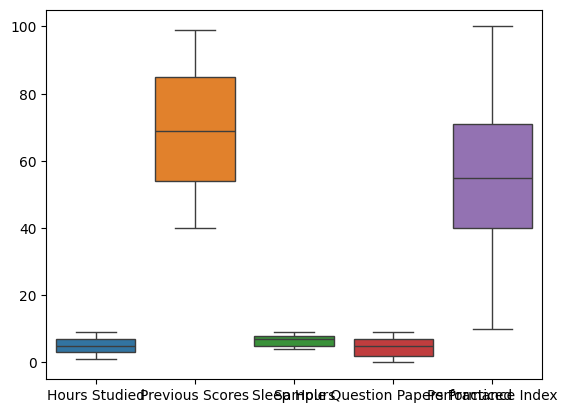

In [64]:
sns.boxplot(df[num_cols])

In [65]:
Xtrain, Xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [66]:
Xtrain[obj_cols].nunique()

Extracurricular Activities    2
dtype: int64

In [67]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


In [68]:
lable_encoder = LabelEncoder()
Xtrain[obj_cols] = lable_encoder.fit_transform(Xtrain[obj_cols])
Xtrain

c:\Users\MAYURESHWAR\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


ValueError: Columns must be same length as key

In [70]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown="ignore")

In [ ]:
# in Onehotencoder we cant directy update 
# Xtrain[obj_cols] = encoder.fit_transform(Xtrain[obj_cols])
values = encoder.fit_transform(Xtrain[obj_cols])
cols = encoder.get_feature_names_out()


In [79]:
# create new column with these value
Xtrain[cols] = values
Xtrain

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,5,49,No,7,5,1.0,0.0
1561,2,48,Yes,7,6,0.0,1.0
1670,2,81,No,7,2,1.0,0.0
6087,2,46,No,6,1,1.0,0.0
6669,8,47,No,9,0,1.0,0.0
...,...,...,...,...,...,...,...
5734,8,50,Yes,6,6,0.0,1.0
5191,4,68,No,9,3,1.0,0.0
5390,9,48,No,7,6,1.0,0.0
860,1,47,No,9,0,1.0,0.0


In [82]:
Xtrain.drop(columns=["Extracurricular Activities"],inplace=True,errors="ignore")
Xtrain

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,5,49,7,5,1.0,0.0
1561,2,48,7,6,0.0,1.0
1670,2,81,7,2,1.0,0.0
6087,2,46,6,1,1.0,0.0
6669,8,47,9,0,1.0,0.0
...,...,...,...,...,...,...
5734,8,50,6,6,0.0,1.0
5191,4,68,9,3,1.0,0.0
5390,9,48,7,6,1.0,0.0
860,1,47,9,0,1.0,0.0


In [ ]:
# Xtest[num_cols] = scaling.traform(Xtest[num_cols])
# xtest_values = 

In [85]:
model = LinearRegression()

In [86]:
model.fit(Xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
